In [ ]:
### Step 0: Setup ----

# Uncomment if running in Google Colab and openpyxl is not already installed
# !pip install openpyxl

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import KNNImputer, SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV

sns.set(style="whitegrid", context="notebook")
np.random.seed(2049)

In [ ]:
# Upload LC_train.xlsx when prompted
from google.colab import files
uploaded = files.upload()

In [ ]:
### Step 1: Pre-processing ----

train = pd.read_excel("LC_train.xlsx")

train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 39 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   addr_state                  100000 non-null  object 
 1   all_util                    99984 non-null   float64
 2   annual_inc                  100000 non-null  float64
 3   application_type            100000 non-null  object 
 4   chargeoff_within_12_mths    100000 non-null  int64  
 5   collections_12_mths_ex_med  100000 non-null  int64  
 6   delinq_2yrs                 100000 non-null  int64  
 7   dti                         99814 non-null   float64
 8   emp_length                  91331 non-null   object 
 9   emp_title                   85080 non-null   object 
 10  fico_range_high             100000 non-null  int64  
 11  fico_range_low              100000 non-null  int64  
 12  home_ownership              100000 non-null  object 
 13  inq_fi         

In [ ]:
# Drop columns:
#   loan_status, revol_bal, tot_cur_bal, revol_util — post-origination "current" variables (data leakage)
#   emp_title, title, zip_code               — high-cardinality free text / identifier
#   mths_since_last_record                   — >90% missing
drop_cols = [
    "loan_status",
    "revol_bal",
    "tot_cur_bal",
    "revol_util",
    "emp_title",
    "title",
    "zip_code",
    "mths_since_last_record",
]

train = train.drop(columns=drop_cols)

print("Train shape:", train.shape)

Train shape: (100000, 31)


In [ ]:
### Step 2: Train / test sets ----
# Data is pre-split. Only the train file is used for all modeling decisions;
# the test file is held out until Step 6 to prevent any leakage.

X_train = train.drop(columns=["int_rate"])
y_train = train["int_rate"]

print("X_train:", X_train.shape)
print("y_train:", y_train.shape)

X_train: (100000, 30)
y_train: (100000,)


In [ ]:
### Step 3: Exploratory data analysis ----

train.describe()

,all_util,annual_inc,chargeoff_within_12_mths,collections_12_mths_ex_med,delinq_2yrs,dti,fico_range_high,fico_range_low,inq_fi,inq_last_12m,...,mths_since_rcnt_il,mths_since_recent_bc,mths_since_recent_inq,open_acc,pub_rec,pub_rec_bankruptcies,tot_coll_amt,total_acc,total_bal_ex_mort,int_rate
count,99984.000000,1.000000e+05,100000.000000,100000.000000,100000.000000,99814.000000,100000.000000,100000.00000,100000.000000,100000.00000,...,97796.000000,99080.000000,90025.000000,100000.00000,100000.000000,100000.000000,100000.000000,100000.000000,1.000000e+05,100000.000000
mean,55.106917,8.851942e+04,0.005980,0.014850,0.219360,21.611879,710.608190,706.60805,1.259150,2.06216,...,17.334349,24.470822,7.007265,12.13205,0.092650,0.092590,155.720050,23.865140,6.072311e+04,12.946763
std,20.141329,9.509197e+04,0.088455,0.134051,0.722998,19.836792,35.617426,35.61688,1.510362,2.32045,...,21.135997,32.311989,5.839270,6.08440,0.296153,0.296037,1558.591764,12.495401,5.833160e+04,5.255559
min,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,664.000000,660.00000,0.000000,0.00000,...,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,2.000000,0.000000e+00,6.460000
25%,41.000000,5.000000e+04,0.000000,0.000000,0.000000,13.400000,684.000000,680.00000,0.000000,0.00000,...,6.000000,5.000000,2.000000,8.00000,0.000000,0.000000,0.000000,15.000000,2.493875e+04,8.190000
50%,55.500000,7.300000e+04,0.000000,0.000000,0.000000,19.770000,704.000000,700.00000,1.000000,1.00000,...,11.000000,14.000000,5.000000,11.00000,0.000000,0.000000,0.000000,22.000000,4.482400e+04,11.710000
75%,69.000000,1.050000e+05,0.000000,0.000000,0.000000,26.980000,729.000000,725.00000,2.000000,3.00000,...,20.000000,31.000000,10.000000,15.00000,0.000000,0.000000,0.000000,30.000000,7.690500e+04,16.120000
max,185.000000,8.645185e+06,6.000000,10.000000,19.000000,999.000000,850.000000,845.00000,39.000000,55.00000,...,432.000000,552.000000,25.000000,69.00000,7.000000,7.000000,291697.000000,129.000000,1.235436e+06,30.990000


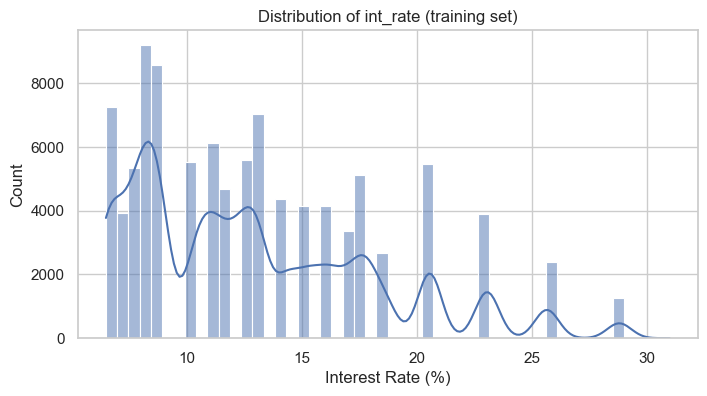

count    100000.000000
mean         12.946763
std           5.255559
min           6.460000
25%           8.190000
50%          11.710000
75%          16.120000
max          30.990000
Name: int_rate, dtype: float64


In [ ]:
# Distribution of the target variable
plt.figure(figsize=(8, 4))
sns.histplot(y_train, bins=50, kde=True)
plt.xlabel("Interest Rate (%)")
plt.title("Distribution of int_rate (training set)")
plt.show()

print(y_train.describe())

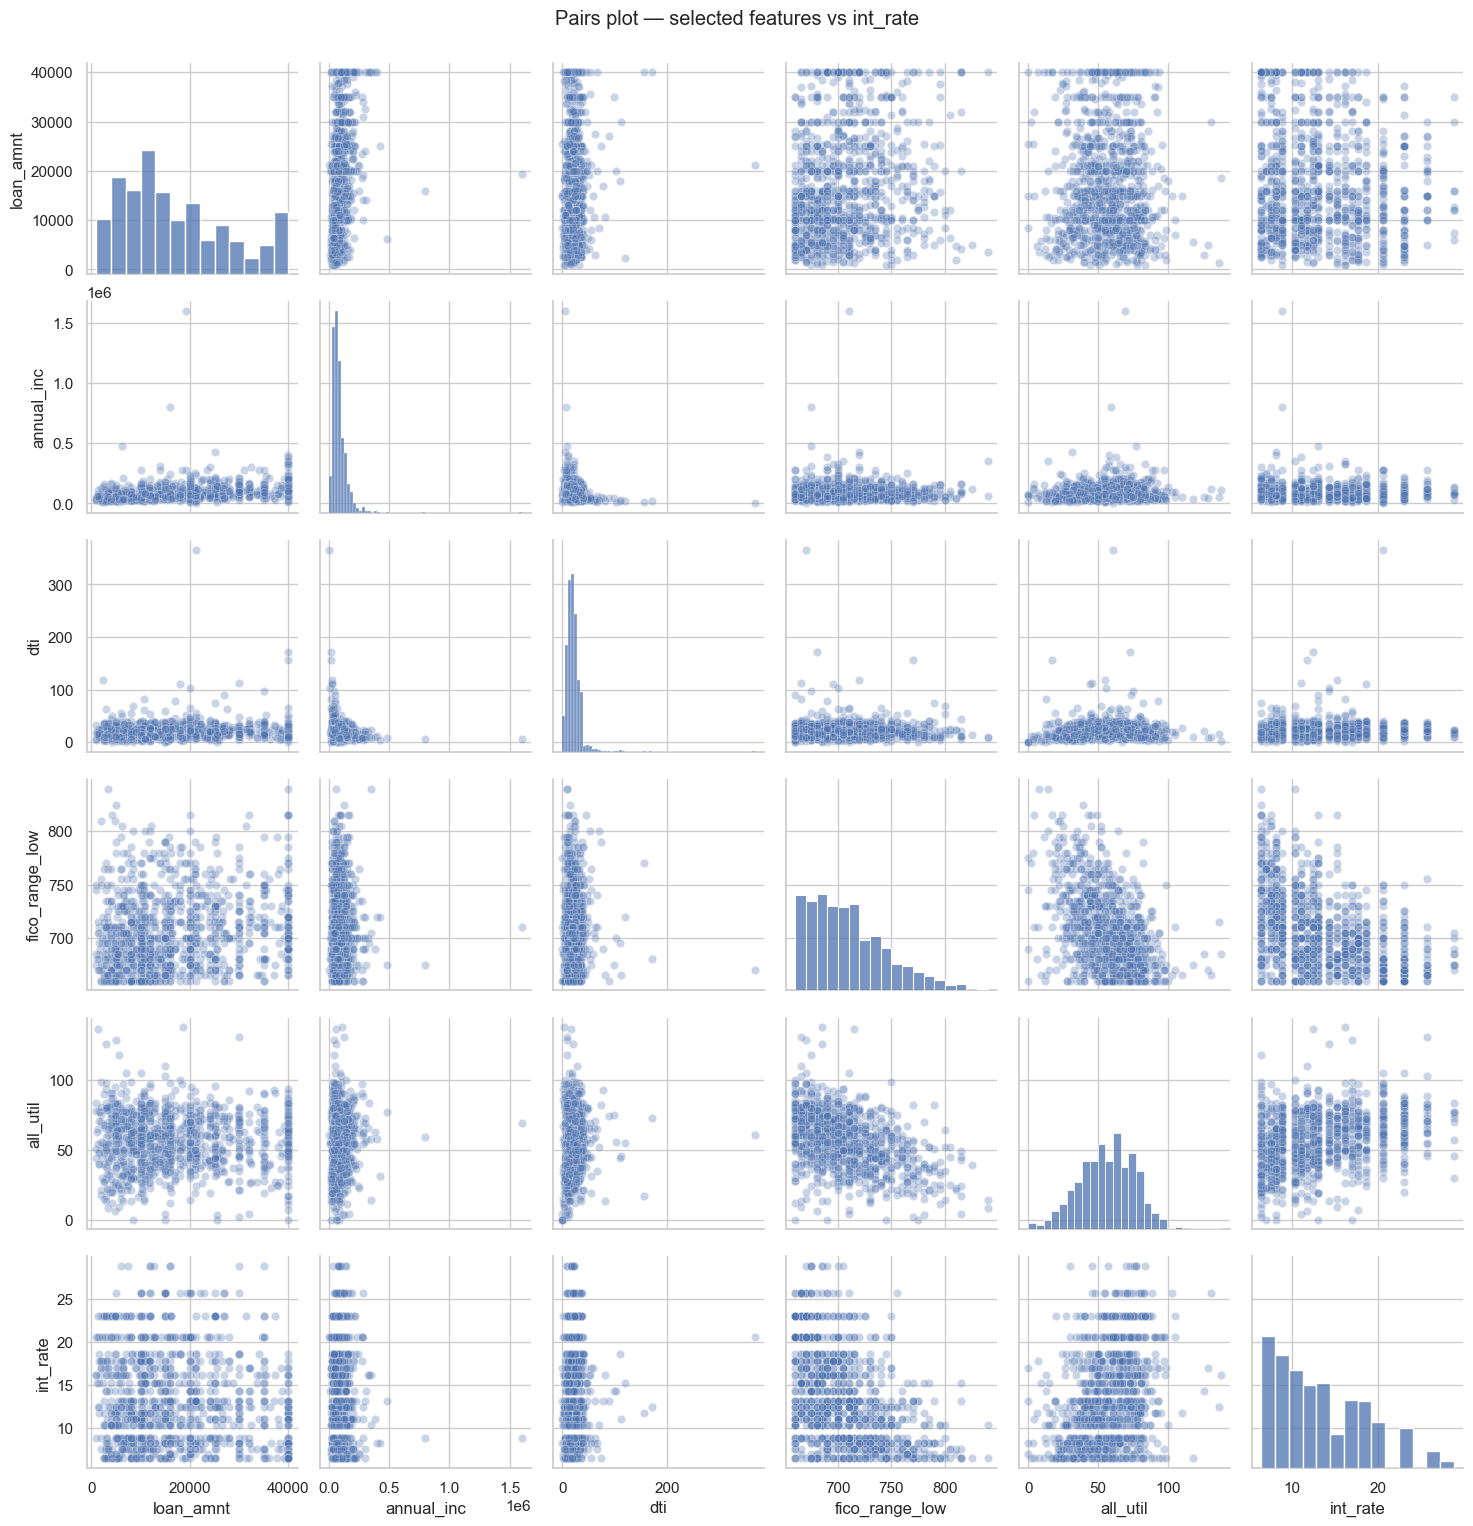

In [ ]:
# Pairplot of selected numeric features vs int_rate
plot_sample = train.sample(n=1000, random_state=2049)

numeric_cols = ["loan_amnt", "annual_inc", "dti", "fico_range_low", "all_util", "int_rate"]

sns.pairplot(
    plot_sample[numeric_cols].dropna(),
    plot_kws={"alpha": 0.3}
)
plt.suptitle("Pairs plot — selected features vs int_rate", y=1.02)
plt.show()

In [ ]:
# Missing value summary
missing = X_train.isnull().sum()
print(missing[missing > 0].sort_values(ascending=False))

mths_since_recent_inq    9975
emp_length               8669
mo_sin_old_il_acct       2204
mths_since_rcnt_il       2204
mths_since_recent_bc      920
dti                       186
all_util                   16
dtype: int64


In [ ]:
### Step 4: Feature engineering ----

# Convert term to numeric ("36 months" → 36, "60 months" → 60)
train["term"] = train["term"].str.extract(r"(\d+)").astype(int)

# Convert emp_length to ordinal numeric
emp_length_map = {
    "< 1 year": 0, "1 year": 1,  "2 years": 2, "3 years": 3,
    "4 years":  4, "5 years": 5, "6 years": 6, "7 years": 7,
    "8 years":  8, "9 years": 9, "10+ years": 10
}
train["emp_length"] = train["emp_length"].map(emp_length_map)

# Redefine X_train to pick up the newly numeric columns
X_train = train.drop(columns=["int_rate"])

numeric_features     = X_train.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = X_train.select_dtypes(include=["object"]).columns.tolist()

print("Numeric features :", numeric_features)
print()
print("Categorical features:", categorical_features)

In [ ]:
numeric_transformer = SimpleImputer(strategy="median")

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

preprocess = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features),
    ]
)

pipe = Pipeline(steps=[
    ("preprocess", preprocess),
    ("tree", DecisionTreeRegressor(random_state=2049))
])

In [ ]:
### Step 5: Feature and Model selection ----

# Subsample training data for faster hyperparameter search
X_cv = X_train.sample(n=40000, random_state=2049)
y_cv = y_train.loc[X_cv.index]

param_grid = {
    "tree__ccp_alpha":        np.linspace(0, 0.5, 20),
    "tree__max_depth":        [5, 10, 15, 20, 30, None],
    "tree__min_samples_leaf": [1, 5, 10, 20, 50],
    "tree__min_samples_split":[2, 10, 20, 50],
    "tree__max_features":     [None, 0.5, 0.75, "sqrt"],
}

grid = GridSearchCV(
    estimator=pipe,
    param_grid=param_grid,
    scoring="r2",
    cv=5,
    n_jobs=-1
)

grid.fit(X_cv, y_cv)

print("Best params:    ", grid.best_params_)
print("Best CV R²:     ", round(grid.best_score_, 4))

# Refit best pipeline on full training data
best_pipe = grid.best_estimator_
best_pipe.fit(X_train, y_train)
best_tree = best_pipe.named_steps["tree"]

In [ ]:
# Full CV results
cv_results = pd.DataFrame(grid.cv_results_)
print(cv_results[["param_tree__ccp_alpha", "param_tree__max_depth",
                   "param_tree__min_samples_leaf", "mean_test_score",
                   "std_test_score"]].sort_values("mean_test_score", ascending=False).to_string())

In [ ]:
# Plot CV R² for all combinations, sorted best to worst
plt.figure(figsize=(10, 4))
plt.bar(
    range(len(cv_results)),
    cv_results["mean_test_score"].sort_values(ascending=False).values
)
plt.axhline(grid.best_score_, color="red", linestyle="--", label=f"Best R² = {grid.best_score_:.4f}")
plt.xlabel("Parameter combination (ranked)")
plt.ylabel("Mean CV R²")
plt.title("GridSearchCV: CV R² across all combinations")
plt.legend()
plt.show()

In [ ]:
### Plot the tree ----

feature_names = best_pipe.named_steps["preprocess"].get_feature_names_out()

plt.figure(figsize=(20, 8))
plot_tree(
    best_tree,
    feature_names=feature_names,
    filled=True,
    rounded=True,
    max_depth=3
)
plt.title("Decision Tree for int_rate (pruned, max_depth=3 shown)")
plt.show()

In [ ]:
from sklearn.metrics import root_mean_squared_error
from sklearn.model_selection import cross_val_score

# In-sample RMSE (optimistic — model has seen this data)
train_preds = best_pipe.predict(X_train)
train_r2    = best_pipe.score(X_train, y_train)
train_rmse  = root_mean_squared_error(y_train, train_preds)

# CV RMSE (honest out-of-sample estimate)
cv_scores = cross_val_score(
    best_pipe, X_train, y_train,
    scoring="neg_root_mean_squared_error",
    cv=5,
    n_jobs=-1
)
cv_rmse = -cv_scores.mean()
cv_rmse_std = cv_scores.std()

print(f"Train R²:   {train_r2:.4f}")
print(f"Train RMSE: {train_rmse:.4f} percentage points  (in-sample)")
print(f"CV RMSE:    {cv_rmse:.4f} (+/- {cv_rmse_std:.4f}) percentage points  (out-of-sample estimate)")

In [ ]:
### Variable importance ----

importances = pd.Series(
    best_tree.feature_importances_,
    index=feature_names
).sort_values(ascending=False)

print("Top 15 feature importances:")
print(importances.head(15))

plt.figure(figsize=(8, 6))
importances.head(15).plot(kind="barh")
plt.gca().invert_yaxis()
plt.xlabel("Importance")
plt.title("Top 15 feature importances (regression tree)")
plt.show()

In [ ]:
### Look at top two most important variables ----

top_two = importances.head(2).index.tolist()
print("Top two variables:", top_two)

# Map encoded feature names back to original columns for plotting
# Top features are likely numeric so we can pull directly from X_train
def get_original_col(encoded_name):
    # numeric features are prefixed with 'num__'
    if encoded_name.startswith("num__"):
        return encoded_name.replace("num__", "")
    return None

orig_cols = [get_original_col(f) for f in top_two]

if all(c is not None for c in orig_cols):
    var_x, var_y = orig_cols
    plt.figure(figsize=(8, 5))
    sns.scatterplot(
        data=train.sample(n=2000, random_state=2049),
        x=var_x,
        y=var_y,
        hue="int_rate",
        palette="coolwarm",
        alpha=0.5
    )
    plt.title(f"{var_y} vs {var_x} colored by int_rate")
    plt.show()

In [ ]:
### Step 6: Predictions and final model evaluation ----
# Test file is loaded here for the first time to ensure no test information
# influenced any earlier modeling decisions.

# Upload LC_test.xlsx when prompted
from google.colab import files
uploaded = files.upload()

test = pd.read_excel("LC_test.xlsx")
test = test.drop(columns=[c for c in drop_cols if c in test.columns])

# Apply the same feature engineering as training
test["term"]       = test["term"].str.extract(r"(\d+)").astype(int)
test["emp_length"] = test["emp_length"].map(emp_length_map)

X_test   = test.drop(columns=["ID"])
test_ids = test["ID"]

test_preds = best_pipe.predict(X_test)

submission = pd.DataFrame({
    "ID":       test_ids,
    "int_rate": test_preds
})

submission.to_csv("LC_predictions.csv", index=False)
files.download("LC_predictions.csv")

print("Predictions saved to LC_predictions.csv")
print(submission.head(10))
print("\nPrediction summary:")
print(submission["int_rate"].describe())